# Import Dataset

/Users/nefelizafeiropoulou/Documents/Data Science Master/Natural Language Processing/NaturalLanguageProcessing-main/NLPvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/nefelizafeiropoulou/.cache/kagglehub/datasets/snap/amazon-fine-food-reviews/versions/2
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                 

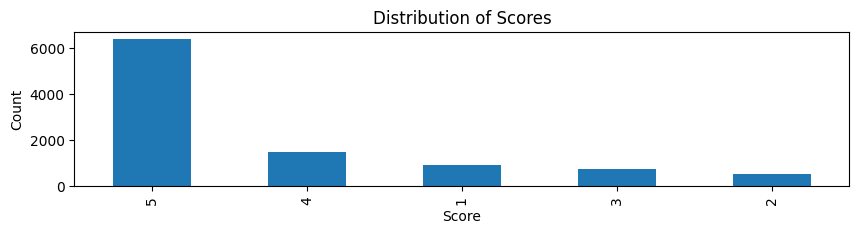

Score: 2 - Summary: OK for smaller dogs
Score: 5 - Summary: Great cookie substitute
Score: 5 - Summary: Yumm
Score: 5 - Summary: Baby Likes This
Score: 4 - Summary: delicious but a  bit  pricy
Score: 5 - Summary: Very good coffee"'
Score: 5 - Summary: Amazingly Good Lemonade
Score: 4 - Summary: a little too salty for my tastes....but....
Score: 5 - Summary: Great Treats!!!
Score: 3 - Summary: Wellness Review Turkey/Salmon
After lowercase transformation:
Score: 5 - Summary: time tested favorite treat
Score: 5 - Summary: moist vanilla beans
Score: 4 - Summary: has good flavor
Score: 4 - Summary: mellow coffee
Score: 5 - Summary: great product for older cat
Score: 5 - Summary: received one packet for review - tastes good!
Score: 5 - Summary: chocolate and banana!
Score: 5 - Summary: nice rice!
Score: 5 - Summary: as adsvertised
Score: 1 - Summary: waste of money
Before: good price for the quantity :)
After: good price for the quantity 

Before: my dog gave it 2 paws up :)
After: my dog ga

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/nefelizafeiropoulou/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/nefelizafeiropoulou/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/nefelizafeiropoulou/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!



Original: great kitty treats
Lemmatized: great kitty treat
  - treats → treat  (POS: NNS)

Original: lifesavers pineapple flavor
Lemmatized: lifesaver pineapple flavor
  - lifesavers → lifesaver  (POS: NNS)

Original: pretty good rice noodles
Lemmatized: pretty good rice noodle
  - noodles → noodle  (POS: NNS)

Original: promising coffee!
Lemmatized: promise coffee!
  - promising → promise  (POS: VBG)

Original: delicious honeycomb covered milk chocolate!
Lemmatized: delicious honeycomb cover milk chocolate!
  - covered → cover  (POS: VBD)

Original: cheaper starbucks
Lemmatized: cheap starbucks
  - cheaper → cheap  (POS: JJR)

Original: awful. not work choking hazzard
Lemmatized: awful. not work choke hazzard
  - choking → choke  (POS: VBG)

Original: stars give stars...
Lemmatized: star give stars...
  - stars → star  (POS: NNS)

Original: bought present
Lemmatized: buy present
  - bought → buy  (POS: VBD)

Original: beware! flavored coffee...
Lemmatized: beware! flavor coffee...
  

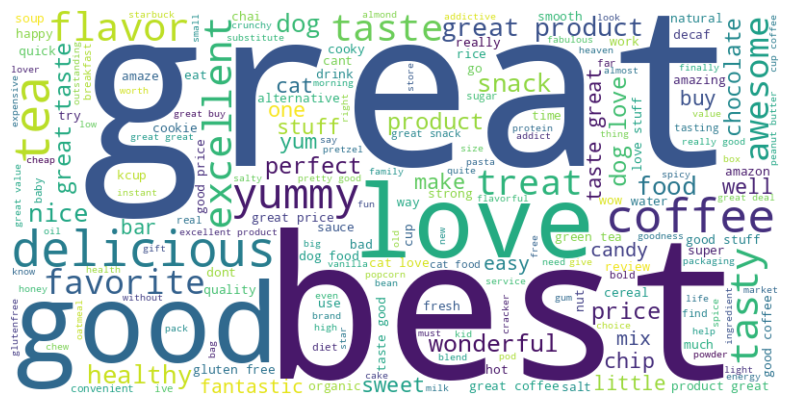

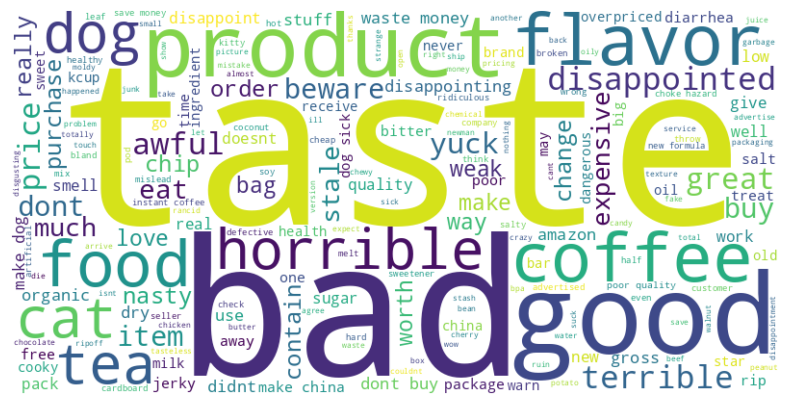

In [1]:
df_summary = 0; df_score = 0
%run ./02-Preprocessing.ipynb

In [2]:
df_summary

0               crunchy good glutenfree sandwich cookies!
1                                       great kitty treat
2                                            coffee taste
3                                         miniwheats big?
4                                             great taste
                              ...                        
9995    frame great rest flimsy thankfully frame hold ...
9996                                  pleasantly suprised
9997                                         super coffee
9998                                               sweet!
9999                                               great!
Name: Summary, Length: 10000, dtype: str

In [3]:
df_score

0       5
1       5
2       3
3       2
4       5
       ..
9995    4
9996    4
9997    5
9998    5
9999    5
Name: Score, Length: 10000, dtype: int64

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_score = le.fit_transform(df_score)

# Embeddings

## TF-IDF

In [5]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_summary, df_score, test_size=0.2, random_state=42, stratify=df_score)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=384,  # Limit features to reduce dimensionality
    min_df=5,           # Minimum document frequency
    max_df=0.8,         # Maximum document frequency (ignore terms that appear in >80% of documents)
    stop_words='english'
)

# Fit and transform the training data
X_train = tfidf_vectorizer.fit_transform(X_train)

In [7]:
X_train[:5].toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 384))

In [8]:
import numpy as np
np.mean(X_train.toarray())

np.float64(0.0031804633398006305)

In [9]:
import random

# Get the number of rows in X_train
num_rows = X_train.shape[0]

# Generate 10 random indices
random_indices = random.sample(range(num_rows), 10)

# Print 10 random lines of X_train
for idx in random_indices:
    print(f"Index: {idx}, Mean: {np.mean(X_train[idx].toarray()[0], axis=0)}")

Index: 533, Mean: 0.0026041666666666665
Index: 2761, Mean: 0.0
Index: 5460, Mean: 0.004362522233601756
Index: 3381, Mean: 0.004414574031138852
Index: 28, Mean: 0.004503446493767061
Index: 5027, Mean: 0.003637096397140207
Index: 4438, Mean: 0.0
Index: 1626, Mean: 0.005124754945604911
Index: 2772, Mean: 0.004480615239897528
Index: 13, Mean: 0.005049292153810811


In [10]:
# Transform the test data
X_test = tfidf_vectorizer.transform(X_test)

In [11]:
# Display the shape of the TF-IDF matrices
print(f"Training TF-IDF matrix shape: {X_train.shape}")
print(f"Testing TF-IDF matrix shape: {X_test.shape}")

Training TF-IDF matrix shape: (8000, 384)
Testing TF-IDF matrix shape: (2000, 384)


In [12]:
# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Number of features (words): {len(feature_names)}")
print(f"Features: {feature_names}")

Number of features (words): 384
Features: ['absolutely' 'actually' 'addict' 'addictive' 'addition' 'aftertaste'
 'almond' 'alternative' 'amaze' 'amazing' 'amazon' 'aroma' 'arrive'
 'available' 'away' 'awesome' 'awful' 'baby' 'bad' 'bag' 'bar' 'bean'
 'beef' 'berry' 'best' 'better' 'beware' 'big' 'bit' 'bite' 'bitter'
 'black' 'bland' 'blend' 'bold' 'bone' 'bottle' 'box' 'brand' 'bread'
 'breakfast' 'broken' 'brown' 'butter' 'buy' 'cake' 'calorie' 'candy'
 'carb' 'cat' 'cereal' 'chai' 'change' 'cheap' 'cheese' 'cherry' 'chew'
 'chewy' 'chicken' 'china' 'chip' 'chips' 'chocolate' 'choice' 'classic'
 'clean' 'cocoa' 'coconut' 'coffee' 'come' 'company' 'container'
 'contains' 'convenient' 'cook' 'cookie' 'cookies' 'cooky' 'corn'
 'cracker' 'crazy' 'cream' 'creamy' 'crunch' 'crunchy' 'cup' 'customer'
 'dark' 'day' 'deal' 'decaf' 'decent' 'definitely' 'delicious' 'delight'
 'delish' 'delivery' 'didnt' 'diet' 'different' 'disappoint'
 'disappointed' 'doesnt' 'dog' 'dogs' 'dont' 'double' 'dres

In [13]:
# Most frequent words
import numpy as np
import pandas as pd

# Get the sum of TF-IDF values for each term across all documents
tfidf_means = np.array(X_train.mean(axis=0)).flatten()

# Create a DataFrame with terms and their TF-IDF sums
term_importance = pd.DataFrame({
    'term': feature_names,
    'tfidf_mean': tfidf_means
})

# Sort by importance (TF-IDF sum)
term_importance = term_importance.sort_values('tfidf_mean', ascending=False)

# Display the top 10 most important terms
print("Top 10 most important terms:")
print(term_importance.head(10))

Top 10 most important terms:
          term  tfidf_mean
151      great    0.064865
147       good    0.050868
199       love    0.040916
24        best    0.032382
339      taste    0.027217
68      coffee    0.027145
342        tea    0.024236
93   delicious    0.022460
262    product    0.021826
103        dog    0.019499


## Word2Vec

In [14]:
X_train, X_test, y_train, y_test = train_test_split(df_summary, df_score, test_size=0.2, random_state=42, stratify=df_score)

In [15]:
# Tokenize the text data for Word2Vec
tokenized_train = [text.split() for text in X_train]
tokenized_test = [text.split() for text in X_test]

In [16]:
tokenized_train[:10]

[['great', 'flavor!', 'hard', 'find', 'stores!'],
 ['good', 'price', 'quantity'],
 ['dissapointing'],
 ['good', 'inexpensive', 'cleanser.'],
 ['best', 'best', 'best'],
 ['excellent', 'dog', 'food!'],
 ['not', 'tasty!'],
 ['yummy', 'throwback!'],
 ['great', 'can', 'tomato', 'salsa'],
 ['great', 'way', 'start', 'day!']]

In [17]:
from gensim.models import Word2Vec
# Define the Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=384, # Dimensionality of the word vectors
    window=5, # Maximum distance between the current and predicted word within a sentence
    min_count=2, # Ignores words with frequency lower than this
    workers=4, # Number of threads to run in parallel
    sg=1, # Training algorithm: 1 for skip-gram; 0 for CBOW
    seed=42
)
print("Training Word2Vec model...")
# Train the model
w2v_model.train(
    tokenized_train, # List of sentences to train
    total_examples=len(tokenized_train), # Number of sentences to train on
    epochs=10 # Number of epochs 
)

Training Word2Vec model...


(157200, 236540)

In [18]:
print(f"Vocabulary size: {len(w2v_model.wv.key_to_index)}")

Vocabulary size: 1942


In [19]:
# Function to create document vectors by averaging word vectors
def document_vector(doc, model):
    # Filter words that are in the model vocabulary
    doc_words = [word for word in doc if word in model.wv]
    if len(doc_words) == 0:
        # Return zeros if no words are in vocabulary
        return np.zeros(model.vector_size)
    # Return the mean of all word vectors in the document
    return np.mean([model.wv[word] for word in doc_words], axis=0)

In [20]:
# Create document vectors for training and testing sets
X_train = np.array([document_vector(doc, w2v_model) for doc in tokenized_train])
X_test = np.array([document_vector(doc, w2v_model) for doc in tokenized_test])

In [21]:
X_train

array([[-0.010243  , -0.02225379,  0.00766061, ...,  0.08036025,
         0.03565917, -0.01711431],
       [-0.01440148, -0.02024066,  0.00756804, ...,  0.07050834,
         0.03588979, -0.01921728],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.01474357, -0.02689375,  0.01370673, ...,  0.08440682,
         0.02946183, -0.01817214],
       [-0.00731662, -0.01656131,  0.01019871, ...,  0.05851508,
         0.02152135, -0.01227071],
       [-0.01073565, -0.0154032 ,  0.00713623, ...,  0.05613625,
         0.03346631, -0.01313024]], shape=(8000, 384))

In [22]:
print(f"Training Word2Vec matrix shape: {X_train.shape}")
print(f"Testing Word2Vec matrix shape: {X_test.shape}")

Training Word2Vec matrix shape: (8000, 384)
Testing Word2Vec matrix shape: (2000, 384)


In [23]:
# Explore some word similarities
my_test_word = "delicious" # Try another common word e.g. food, price, service, etc.
try:
    # Find words most similar
    print(f"\nWords most similar to '{my_test_word}':")
    for word, similarity in w2v_model.wv.most_similar(my_test_word, topn=5):
        print(f"{word}: {similarity:.4f}")
except KeyError:
    print(f"Word '{my_test_word}' not in vocabulary. Try another common word.")


Words most similar to 'delicious':
thats: 0.9988
cake: 0.9986
soda: 0.9986
glutenfree: 0.9986
addition: 0.9985


# ML Models

## Logistic Regression

In [24]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score

# Initialize the Logistic Regression model
# Use 'multinomial' solver for multi-class classification
lr_model = LogisticRegression(
    solver='lbfgs',             # Efficient solver for multinomial logistic regression
    max_iter=1000,              # Increase max iterations to ensure convergence
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all available cores
)

In [25]:
# Train the model
print("Training Logistic Regression model...")
lr_model.fit(X_train, y_train)

Training Logistic Regression model...


/Users/nefelizafeiropoulou/Documents/Data Science Master/Natural Language Processing/NaturalLanguageProcessing-main/NLPvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"n_jobs n_jobs: int, default=NoneDoes not have any effect... deprecated:: 1.8 `n_jobs` is deprecated in version 1.8 and will be removed in 1.10.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None


In [26]:
# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate the model
print("\nLogistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Logistic Regression Model Evaluation:
Accuracy: 0.6390


In [27]:
# Display detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))


Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       178
           2       0.00      0.00      0.00       102
           3       0.00      0.00      0.00       150
           4       0.00      0.00      0.00       291
           5       0.64      1.00      0.78      1279

    accuracy                           0.64      2000
   macro avg       0.13      0.20      0.16      2000
weighted avg       0.41      0.64      0.50      2000



/Users/nefelizafeiropoulou/Documents/Data Science Master/Natural Language Processing/NaturalLanguageProcessing-main/NLPvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nefelizafeiropoulou/Documents/Data Science Master/Natural Language Processing/NaturalLanguageProcessing-main/NLPvenv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nefelizafeiropoulou/Documents/Data Science Master/Natural Language Processing/NaturalLanguageProcessing-main/NLPvenv/lib/pyth

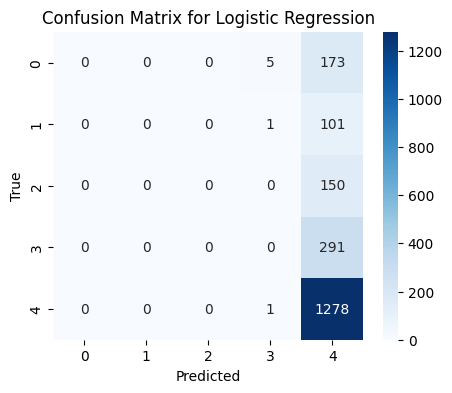

In [28]:
# Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(set(y_test)), 
            yticklabels=sorted(set(y_test)))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

## Random Forest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)
# Make predictions
y_pred = rf_model.predict(X_test)
# Evaluate the model
print("\nRandom Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
# Display detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))


Random Forest Model Evaluation:
Accuracy: 0.6175

Classification Report:
              precision    recall  f1-score   support

           1       0.35      0.23      0.28       178
           2       0.19      0.08      0.11       102
           3       0.19      0.09      0.12       150
           4       0.26      0.13      0.17       291
           5       0.70      0.89      0.78      1279

    accuracy                           0.62      2000
   macro avg       0.34      0.28      0.29      2000
weighted avg       0.54      0.62      0.56      2000



## Gradient Boosting (XGBoost)

In [30]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
# Make predictions
y_pred = xgb_model.predict(X_test)
# Evaluate the model
print("\nXGBoost Classification Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
# Display detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))


XGBoost Classification Model Evaluation:
Accuracy: 0.6520

Classification Report:
              precision    recall  f1-score   support

           1       0.40      0.25      0.31       178
           2       0.35      0.13      0.19       102
           3       0.33      0.13      0.18       150
           4       0.35      0.12      0.18       291
           5       0.70      0.93      0.80      1279

    accuracy                           0.65      2000
   macro avg       0.43      0.31      0.33      2000
weighted avg       0.58      0.65      0.59      2000

